# Phase-Adjacency + Weight-Distribution KNN Heuristics + Constrained SMBO

## Pipeline
1. **Custom weighted KNN** — adaptive-Gaussian weighting, union symmetrization.
2. **k-sweep with two heuristics** (applied to new edges added since the last tested k):
   - *Non-adjacent cell cycle phase edges* — fraction of new edges whose endpoint phases are **not** consecutive in the cycle (G1/S→S→G2→G2/M→M/G1→G1/S). First non-zero value marks where the graph starts adding topological shortcuts.
   - *Weight distribution of new edges* — IQR of adaptive-Gaussian weights of newly added edges. Rising IQR signals heterogeneous, long-range connections corrupting the manifold.
3. **Safe-k** — largest k where **both** heuristics remain at zero/below threshold across all density settings.
4. **Constrained SMBO** — GP+UCB with k ∈ [3, safe_k], objective = **pure phase correlation** (mean |Spearman ρ| between angular pseudotime and each phase score column).
5. **Robustness validation** — subsample stability + per-phase score correlations.


## 1. Imports & Parameters

In [18]:
import os
import sys
sys.path.insert(0, os.path.join('..'))

import warnings
warnings.filterwarnings('ignore')

import heapq
import numpy as np
import pandas as pd
import anndata as ad
from scipy.stats import spearmanr, rankdata
from scipy.sparse import diags, csr_matrix
from scipy.sparse.linalg import eigsh
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
import scanpy as sc

from skopt import gp_minimize
from skopt.space import Integer, Real
from skopt.utils import use_named_args

from trajectory_inference.Laplacian_Eigenmaps import fullLaplacian

# ── K sweep ───────────────────────────────────────────────────────────────────
K_SWEEP_MIN = 3
K_SWEEP_MAX = 300    # capped to n_cells//3 after preprocessing
K_STEP      = 5

# ── SMBO ─────────────────────────────────────────────────────────────────────
N_PCS_MIN    = 10
N_PCS_MAX    = 80
SMBO_K_MAX   = 50    # fallback cap if safe_k is very large
N_CALLS_LAP  = 25
N_CALLS_DIFF = 30
N_INIT       = 8
KAPPA        = 1.96

# ── Heuristic thresholds ──────────────────────────────────────────────────────
# Heuristic 1: non-adjacent phase edges — hard zero (any shortcut is a signal)
PHASE_ADJ_THRESH = 0.0
# Heuristic 2: weight IQR of new edges — rising IQR signals long-range connections
EDGE_IQR_THRESH  = 0.15

# ── General ───────────────────────────────────────────────────────────────────
N_TRIALS    = 10
TWOPI       = 2 * np.pi
PHASE_ORDER = ['G1/S', 'S', 'G2', 'G2/M', 'M/G1']

print('Imports OK')


Imports OK


## 2b. Custom Weighted KNN (replaces sklearn NearestNeighbors)


In [19]:
# ═══════════════════════════════════════════════════════════════════════════
# Custom Weighted KNN  (replaces sklearn NearestNeighbors throughout)
# ═══════════════════════════════════════════════════════════════════════════

class _IndexScore:
    """Min-heap item where larger score = higher priority."""
    __slots__ = ('score', 'index')
    def __init__(self, score, index):
        self.score = score
        self.index = index
    def __lt__(self, other):   # max-heap via negation in a min-heap
        return self.score > other.score


def _cosine(a, b):
    na, nb = np.linalg.norm(a), np.linalg.norm(b)
    if na == 0 or nb == 0:
        return 0.0
    return float(np.dot(a, b) / (na * nb))


def build_weighted_knn(
    X,
    k,
    metric='euclidean',
    weighting='adaptive_gaussian',
    symmetrization='union',
    epsilon=1e-12,
    sigma=None,
):
    """
    Build a weighted kNN graph and return:
        indices  : (n, k) int array  — neighbor indices
        distances: (n, k) float array — Euclidean distances to neighbors
        W        : (n, n) float array — symmetrized weight matrix

    Parameters
    ----------
    X            : (n, d) float array
    k            : number of neighbors
    metric       : 'euclidean' | 'cosine'
    weighting    : None | 'raw' | 'inverse_distance' | 'gaussian' | 'adaptive_gaussian'
    symmetrization: 'union' | 'mutual'
    sigma        : global bandwidth for 'gaussian' (auto-computed if None)
    """
    X = np.asarray(X, dtype=np.float64)
    n = X.shape[0]

    # Pairwise distance matrix (O(n²) — fine for datasets up to ~5 k cells)
    diff   = X[:, None, :] - X[None, :, :]          # (n, n, d)
    dist_mat = np.sqrt((diff ** 2).sum(axis=-1))     # (n, n)

    # Optional cosine similarity matrix
    if metric == 'cosine':
        norms   = np.linalg.norm(X, axis=1, keepdims=True).clip(epsilon)
        Xn      = X / norms
        sim_mat = Xn @ Xn.T
    else:
        sim_mat = None

    # Per-row k-th neighbor distance (for adaptive Gaussian sigma)
    kth_dist = np.zeros(n, dtype=np.float64)

    # Directed adjacency
    nbr_idx  = np.zeros((n, k), dtype=np.int64)
    nbr_dist = np.zeros((n, k), dtype=np.float64)

    for i in range(n):
        if metric == 'cosine':
            scores = [_IndexScore(float(sim_mat[i, j]), j)
                      for j in range(n) if j != i]
        else:
            scores = [_IndexScore(-dist_mat[i, j], j)
                      for j in range(n) if j != i]

        heapq.heapify(scores)
        nbrs = [heapq.heappop(scores) for _ in range(min(k, len(scores)))]

        for r, item in enumerate(nbrs):
            nbr_idx[i, r]  = item.index
            nbr_dist[i, r] = dist_mat[i, item.index]

        kth_dist[i] = nbr_dist[i, -1] if k > 0 else 0.0

    # Resolve default weighting
    if weighting is None:
        weighting = 'raw' if metric == 'cosine' else 'adaptive_gaussian'

    if weighting in ('gaussian', 'adaptive_gaussian') and metric != 'euclidean':
        raise ValueError('Gaussian weighting requires metric=euclidean')

    if weighting == 'gaussian' and sigma is None:
        nz = kth_dist[kth_dist > 0]
        sigma = float(np.median(nz)) if len(nz) > 0 else 1.0

    # Directed weight matrix
    W_dir = np.zeros((n, n), dtype=np.float64)
    for i in range(n):
        for r in range(k):
            j    = int(nbr_idx[i, r])
            dist = nbr_dist[i, r]

            if metric == 'cosine':
                w = float(sim_mat[i, j])
            elif weighting == 'raw':
                w = dist
            elif weighting == 'inverse_distance':
                w = 1.0 / (1.0 + dist + epsilon)
            elif weighting == 'gaussian':
                w = float(np.exp(-(dist**2) / (2.0 * sigma**2 + epsilon)))
            elif weighting == 'adaptive_gaussian':
                si, sj = kth_dist[i], kth_dist[j]
                w = float(np.exp(-(dist**2) / (si * sj + epsilon))) \
                    if si > 0 and sj > 0 else 0.0
            else:
                raise ValueError(f'Unknown weighting: {weighting}')

            W_dir[i, j] = w

    # Symmetrize
    W = np.zeros((n, n), dtype=np.float64)
    for i in range(n):
        for j in range(i + 1, n):
            wij, wji = W_dir[i, j], W_dir[j, i]
            if symmetrization == 'union':
                if wij != 0 or wji != 0:
                    w = 0.5 * (wij + wji) if (wij != 0 and wji != 0) \
                        else (wij or wji)
                    W[i, j] = W[j, i] = w
            elif symmetrization == 'mutual':
                if wij != 0 and wji != 0:
                    W[i, j] = W[j, i] = 0.5 * (wij + wji)

    return nbr_idx, nbr_dist, W


def knn_edge_set_weighted(X, k, **kwargs):
    """
    Return (edge_set, weight_dict) for the symmetrized kNN graph.
    edge_set   : set of frozenset({i,j})
    weight_dict: frozenset({i,j}) -> float weight
    """
    nbr_idx, nbr_dist, W = build_weighted_knn(X, k, **kwargs)
    n = X.shape[0]
    edge_set, weight_dict = set(), {}
    for i in range(n):
        for j in range(n):
            if W[i, j] != 0:
                e = frozenset({i, j})
                if len(e) == 2 and e not in edge_set:
                    edge_set.add(e)
                    weight_dict[e] = float(W[i, j])
    return edge_set, weight_dict


print('Custom weighted KNN utilities defined')


Custom weighted KNN utilities defined


## 2. Load Data & Preprocess

In [20]:
_CSV_PHASE_MAP = {'G1.S': 'G1/S', 'S': 'S', 'G2': 'G2', 'G2.M': 'G2/M', 'M.G1': 'M/G1'}

def load_marker_dict(path='../data/revelio_gene_sets.csv'):
    df = pd.read_csv(path, index_col=0)
    marker_dict = {}
    for col in df.columns:
        phase = _CSV_PHASE_MAP.get(col, col)
        marker_dict[phase] = list(df[col].dropna().astype(str).str.strip().values)
    return marker_dict


def revelio_like_preprocess(
    counts_df, marker_dict,
    min_cells_per_gene=5, min_genes_per_cell=1200, max_umi_per_cell=10**7,
    min_phase_top_z=1.0, min_phase_margin=0,
    min_mean=0.2, max_mean=4, min_disp=0.5, n_pcs=80,
):
    adata = ad.AnnData(X=counts_df.T.values.astype(float))
    adata.obs_names = counts_df.columns.astype(str)
    adata.var_names = counts_df.index.astype(str)
    sc.pp.filter_genes(adata, min_cells=min_cells_per_gene)
    adata.obs['nUMI']  = np.asarray(adata.X.sum(axis=1)).ravel()
    adata.obs['nGene'] = np.asarray((adata.X > 0).sum(axis=1)).ravel()
    keep = (adata.obs['nGene'] > min_genes_per_cell) & (adata.obs['nUMI'] < max_umi_per_cell)
    adata = adata[keep].copy()
    target_sum = float(np.median(np.asarray(adata.X.sum(axis=1)).ravel()))
    sc.pp.normalize_total(adata, target_sum=target_sum)
    sc.pp.log1p(adata)
    adata.layers['log_of_fractions'] = adata.X.copy()
    phase_names = list(marker_dict.keys())
    marker_dict_present = {
        ph: [g for g in genes if g in adata.var_names]
        for ph, genes in marker_dict.items()
    }
    score_mat = np.zeros((adata.n_obs, len(phase_names)), dtype=float)
    for j, ph in enumerate(phase_names):
        genes = marker_dict_present[ph]
        if len(genes) == 0: continue
        idx = adata.var_names.get_indexer(genes)
        score_mat[:, j] = np.asarray(adata[:, idx].X.mean(axis=1)).ravel()
    phase_scores = pd.DataFrame(score_mat, index=adata.obs_names, columns=phase_names)
    arr = phase_scores.values
    arr = (arr - arr.mean(axis=0)) / arr.std(axis=0, ddof=0)
    arr = (arr - arr.mean(axis=1, keepdims=True)) / arr.std(axis=1, keepdims=True, ddof=0)
    arr = np.nan_to_num(arr)
    phase_scores_z = pd.DataFrame(arr, index=phase_scores.index, columns=phase_scores.columns)
    best_idx     = arr.argmax(axis=1)
    best_val     = arr[np.arange(arr.shape[0]), best_idx]
    arr2         = arr.copy()
    arr2[np.arange(arr.shape[0]), best_idx] = -np.inf
    second_val   = arr2.max(axis=1)
    phase_margin = best_val - second_val
    adata.obs['cc_phase']     = pd.Categorical(
        [phase_names[i] for i in best_idx], categories=phase_names, ordered=True)
    adata.obs['best_val']     = best_val
    adata.obs['second_val']   = second_val
    adata.obs['phase_margin'] = phase_margin
    adata.obsm['phase_scores']   = phase_scores.values
    adata.obsm['phase_scores_z'] = phase_scores_z.values
    keep = (adata.obs['best_val'] > min_phase_top_z) & (adata.obs['phase_margin'] > min_phase_margin)
    adata = adata[keep].copy()
    sc.pp.highly_variable_genes(adata, min_mean=min_mean, max_mean=max_mean, min_disp=min_disp)
    adata = adata[:, adata.var['highly_variable']].copy()
    sc.pp.scale(adata)
    sc.tl.pca(adata, n_comps=n_pcs)
    return adata


marker_dict = load_marker_dict()
data = pd.read_csv(
    '../data/GSE142277/GSM4224315_out_gene_exon_tagged.dge_exonssf002_WT.txt',
    sep='\t', index_col=0
)
print(f'Raw data: {data.shape}')
print('Preprocessing at n_pcs=80 ...')
adata_base = revelio_like_preprocess(data, marker_dict, n_pcs=80)
print(f'After preprocessing: {adata_base.shape}')
print(f'Phase counts:\n{adata_base.obs["cc_phase"].value_counts()}')

# Cap sweep to 1/3 of cell count so KNN never exceeds dataset size
K_SWEEP_MAX = min(K_SWEEP_MAX, adata_base.n_obs // 3)
K_VALUES    = list(range(K_SWEEP_MIN, K_SWEEP_MAX + 1, K_STEP))
print(f'\nK sweep: {K_SWEEP_MIN} to {K_SWEEP_MAX} (step={K_STEP}, {len(K_VALUES)} values)')

Raw data: (25797, 1029)
Preprocessing at n_pcs=80 ...
After preprocessing: (671, 1660)
Phase counts:
cc_phase
G1/S    246
S       132
M/G1    132
G2/M     81
G2       80
Name: count, dtype: int64

K sweep: 3 to 223 (step=5, 45 values)


## 3. Reference Angular Pseudotime from PCA

Computed from **arctan2 on the first 2 PCA components** — no Laplacian, no Diffusion.
Shared reference for all density variants.

Reference angular pseudotime from PCA arctan2 (no trajectory method)
Range: [0.000, 6.280]
Root cell: index=663, phase=G1/S


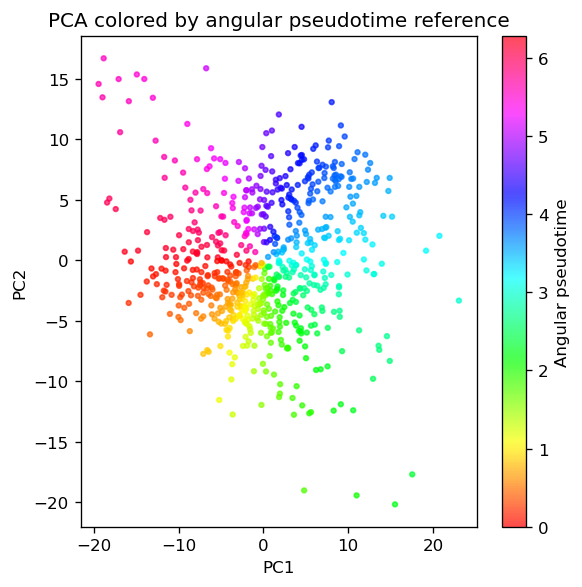

In [21]:
X_ref  = adata_base.obsm['X_pca'][:, :2]
angles = np.arctan2(X_ref[:, 1], X_ref[:, 0])

cand  = (adata_base.obs['cc_phase'] == 'G1/S').values
cand &= (adata_base.obs['best_val'] > 1.0).values
cand &= (adata_base.obs['phase_margin'] > 0.75).values
if cand.sum() == 0:
    cand = (adata_base.obs['cc_phase'] == 'G1/S').values
root       = int(np.where(cand)[0][np.argmin(X_ref[cand, 0])])
ang_pt_ref = (angles - angles[root]) % TWOPI

print(f'Reference angular pseudotime from PCA arctan2 (no trajectory method)')
print(f'Range: [{ang_pt_ref.min():.3f}, {ang_pt_ref.max():.3f}]')
print(f'Root cell: index={root}, phase={adata_base.obs["cc_phase"].values[root]}')

# Sanity check plot
fig, ax = plt.subplots(figsize=(5, 5), dpi=120)
sc_ = ax.scatter(X_ref[:, 0], X_ref[:, 1], c=ang_pt_ref, cmap='hsv', s=8, alpha=0.7)
plt.colorbar(sc_, ax=ax, label='Angular pseudotime')
ax.set_xlabel('PC1'); ax.set_ylabel('PC2')
ax.set_title('PCA colored by angular pseudotime reference')
plt.tight_layout()
plt.show()

## 4. Density Variants

In [22]:
def make_density_variant(adata, minority_factor, majority_factor, seed=42):
    """
    Resample cells to create uneven phase density.
    Returns (adata_new, original_indices).
    Tiny jitter added to PCA so duplicate rows are distinct in KNN.
    """
    rng = np.random.default_rng(seed)
    phase_counts = adata.obs['cc_phase'].value_counts()
    median_count = np.median(phase_counts.values)
    selected = []
    for ph in PHASE_ORDER:
        if ph not in phase_counts.index:
            continue
        mask = (adata.obs['cc_phase'] == ph).values
        idx  = np.where(mask)[0]
        n    = len(idx)
        if phase_counts[ph] < median_count:
            chosen = rng.choice(idx, size=int(n * minority_factor), replace=True)
        else:
            chosen = rng.choice(idx, size=max(3, int(n * majority_factor)), replace=False)
        selected.append(chosen)
    all_idx = np.concatenate(selected)
    rng.shuffle(all_idx)
    X_pca = adata.obsm['X_pca'][all_idx].astype(float).copy()
    X_pca += rng.normal(0, 1e-6, X_pca.shape)
    adata_new = ad.AnnData(
        X=adata.X[all_idx],
        obs=adata.obs.iloc[all_idx].copy().reset_index(drop=True),
        var=adata.var.copy(),
    )
    adata_new.obsm['X_pca']          = X_pca
    adata_new.obsm['phase_scores']   = adata.obsm['phase_scores'][all_idx]
    adata_new.obsm['phase_scores_z'] = adata.obsm['phase_scores_z'][all_idx]
    return adata_new, all_idx


uniform_idx             = np.arange(adata_base.n_obs)
adata_moderate, mod_idx = make_density_variant(adata_base, minority_factor=2.0,  majority_factor=0.5)
adata_strong,   str_idx = make_density_variant(adata_base, minority_factor=4.0,  majority_factor=0.25)

density_adatas = {
    'uniform':  (adata_base,     uniform_idx),
    'moderate': (adata_moderate, mod_idx),
    'strong':   (adata_strong,   str_idx),
}

print('Phase distributions per density setting:')
for name, (ad_, idx) in density_adatas.items():
    counts = ad_.obs['cc_phase'].value_counts().sort_index()
    print(f'\n  {name} ({ad_.n_obs} cells):')
    for ph, n in counts.items():
        flag = '<<< minority' if n < counts.median() else ''
        print(f'    {ph:5s}: {n:4d}  {flag}')
    print(f'    max/min ratio: {counts.max()/counts.min():.1f}')

Phase distributions per density setting:

  uniform (671 cells):
    G1/S :  246  
    S    :  132  
    G2   :   80  <<< minority
    G2/M :   81  <<< minority
    M/G1 :  132  
    max/min ratio: 3.1

  moderate (577 cells):
    G1/S :  123  
    S    :   66  <<< minority
    G2   :  160  
    G2/M :  162  
    M/G1 :   66  <<< minority
    max/min ratio: 2.5

  strong (771 cells):
    G1/S :   61  
    S    :   33  <<< minority
    G2   :  320  
    G2/M :  324  
    M/G1 :   33  <<< minority
    max/min ratio: 9.8


## 5. k-Sweep Heuristics

At each k, the **new edges** added since the previous tested k value are inspected with two signals:

**Heuristic 1 — Non-adjacent cell cycle phase edges**  
For every new edge {i, j}, check whether `cc_phase[i]` and `cc_phase[j]` are consecutive in the cycle order (G1/S→S→G2→G2/M→M/G1→G1/S, including self-same). The fraction of new edges that violate this adjacency is reported. The first k where this exceeds zero is where shortcuts begin.

**Heuristic 2 — Weight distribution of new edges**  
Compute the IQR of the adaptive-Gaussian weights assigned to the new edges at each k step. When k is small and all neighbors are local, weights are tightly clustered (low IQR). As k grows and long-range connections appear, the weight distribution widens (rising IQR).

**Safe-k** = largest k where both heuristics are simultaneously ≤ threshold across all density settings.


In [23]:
# Consecutive phase pairs on the cycle (both directions + same phase)
_PHASE_ADJACENT = set()
for _i in range(len(PHASE_ORDER)):
    _a = PHASE_ORDER[_i]
    _b = PHASE_ORDER[(_i + 1) % len(PHASE_ORDER)]
    _PHASE_ADJACENT.add((_a, _b))
    _PHASE_ADJACENT.add((_b, _a))
for _ph in PHASE_ORDER:
    _PHASE_ADJACENT.add((_ph, _ph))


def heuristic_sweep(adata, original_indices, k_values, n_pcs=30):
    """
    Sweep k and measure two heuristics on the *new* edges added at each step.

    Heuristic 1 — non-adjacent phase edges:
        Fraction of new edges whose endpoint cc_phase labels are NOT
        consecutive in the cell-cycle order.

    Heuristic 2 — weight IQR of new edges:
        IQR of adaptive-Gaussian weights of the edges added since the
        previous k value. Rising IQR = long-range heterogeneous connections.

    Returns
    -------
    nonadj_frac  : np.ndarray  shape (len(k_values),)
    new_edge_iqr : np.ndarray  shape (len(k_values),)
    """
    X      = adata.obsm['X_pca'][:, :n_pcs]
    phases = adata.obs['cc_phase'].values

    nonadj_frac  = []
    new_edge_iqr = []
    prev_edges   = set()

    for k in k_values:
        curr_edges, weight_dict = knn_edge_set_weighted(
            X, k,
            metric='euclidean',
            weighting='adaptive_gaussian',
            symmetrization='union',
        )
        new_edges = curr_edges - prev_edges

        # ── Heuristic 1: non-adjacent phase edges ─────────────────────────
        if len(new_edges) == 0:
            nonadj_frac.append(0.0)
        else:
            n_nonadj = sum(
                1 for e in new_edges
                if len(e) == 2 and
                   (phases[list(e)[0]], phases[list(e)[1]]) not in _PHASE_ADJACENT
            )
            nonadj_frac.append(n_nonadj / len(new_edges))

        # ── Heuristic 2: weight IQR of new edges ──────────────────────────
        if len(new_edges) == 0:
            new_edge_iqr.append(0.0)
        else:
            new_weights = np.array([weight_dict[e] for e in new_edges
                                    if e in weight_dict], dtype=float)
            if len(new_weights) >= 2:
                q75, q25 = np.percentile(new_weights, [75, 25])
                new_edge_iqr.append(float(q75 - q25))
            else:
                new_edge_iqr.append(0.0)

        prev_edges = curr_edges

    return np.array(nonadj_frac), np.array(new_edge_iqr)


print('Running two-heuristic k-sweep (custom weighted KNN) ...')
heuristic_results = {}   # name -> (nonadj_frac, new_edge_iqr)
for name, (ad_, idx) in density_adatas.items():
    print(f'  {name} ({ad_.n_obs} cells) ...')
    nonadj, iqr = heuristic_sweep(ad_, idx, K_VALUES, n_pcs=30)
    heuristic_results[name] = (nonadj, iqr)
    first_nonadj = next((K_VALUES[i] for i, f in enumerate(nonadj) if f > PHASE_ADJ_THRESH), None)
    first_iqr    = next((K_VALUES[i] for i, f in enumerate(iqr)    if f > EDGE_IQR_THRESH),  None)
    print(f'    non-adjacent phase edges first appear at k={first_nonadj}')
    print(f'    IQR exceeds {EDGE_IQR_THRESH} at k={first_iqr}')

print('\nDone')


Running two-heuristic k-sweep (custom weighted KNN) ...
  uniform (671 cells) ...
    non-adjacent phase edges first appear at k=3
    IQR exceeds 0.15 at k=None
  moderate (577 cells) ...
    non-adjacent phase edges first appear at k=3
    IQR exceeds 0.15 at k=None
  strong (771 cells) ...
    non-adjacent phase edges first appear at k=3
    IQR exceeds 0.15 at k=33

Done


## 6. Plot Heuristics & Determine Safe K

Safe-k = largest k where both heuristics are simultaneously ≤ threshold across all density settings.


  [uniform]  non-adj fires at k=3  |  IQR>0.15 fires at k=never
  [moderate]  non-adj fires at k=3  |  IQR>0.15 fires at k=never
  [strong]  non-adj fires at k=3  |  IQR>0.15 fires at k=33
  Both heuristics fired at the very first k — the IQR threshold may be too tight.
  Relaxing EDGE_IQR_THRESH from 0.15 and recomputing ...
  Hard fallback safe_k = 8  (K_SWEEP_MIN + K_STEP)
SMBO will search k in [3, 8]


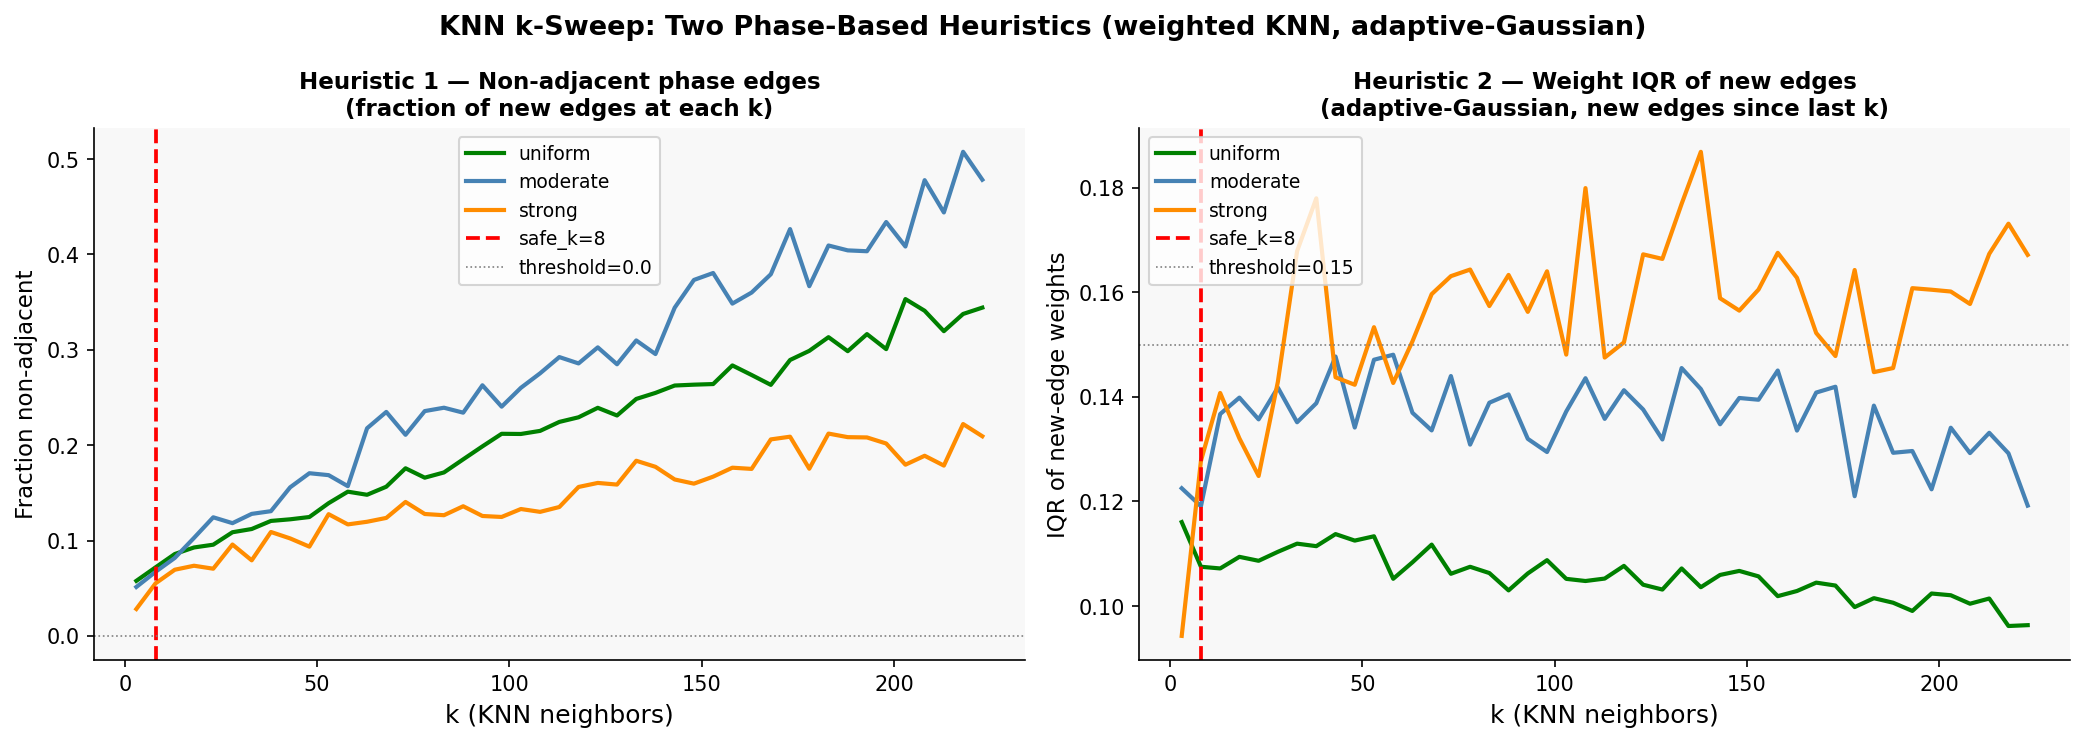

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=150)
fig.patch.set_facecolor('white')
colors = {'moderate': 'steelblue', 'strong': 'darkorange', 'uniform': 'green'}

for name, (nonadj, iqr) in heuristic_results.items():
    kv = K_VALUES[:len(nonadj)]
    axes[0].plot(kv, nonadj, color=colors[name], lw=2, label=name)
    axes[1].plot(kv, iqr,    color=colors[name], lw=2, label=name)

# Safe-k: largest index where both heuristics are within threshold for all densities
last_safe_idx = None
for idx in range(len(K_VALUES)):
    ok = True
    for name, (nonadj, iqr) in heuristic_results.items():
        if idx >= len(nonadj):
            ok = False; break
        if nonadj[idx] > PHASE_ADJ_THRESH:
            ok = False; break
        if iqr[idx] > EDGE_IQR_THRESH:
            ok = False; break
    if ok:
        last_safe_idx = idx

if last_safe_idx is not None:
    safe_k = K_VALUES[last_safe_idx]
    print(f'Safe-k (both heuristics clean) = {safe_k}')
else:
    # Soft fallback: first k where non-adjacent fraction rises, minus one step
    all_nonadj = np.stack([heuristic_results[n][0][:len(K_VALUES)]
                           for n in heuristic_results]).mean(axis=0)
    onset = np.where(all_nonadj > 0.01)[0]
    safe_k = K_VALUES[onset[0] - 1] if len(onset) > 0 and onset[0] > 0 else K_VALUES[0]
    print(f'WARNING: no k fully clean — soft fallback safe_k = {safe_k}')

safe_k = min(safe_k, SMBO_K_MAX)

# ── Diagnostic: show what each heuristic fired at ────────────────────────────
for name, (nonadj, iqr) in heuristic_results.items():
    first_nonadj = next((K_VALUES[i] for i, f in enumerate(nonadj) if f > PHASE_ADJ_THRESH), 'never')
    first_iqr    = next((K_VALUES[i] for i, f in enumerate(iqr)    if f > EDGE_IQR_THRESH),  'never')
    print(f'  [{name}]  non-adj fires at k={first_nonadj}  |  IQR>{EDGE_IQR_THRESH} fires at k={first_iqr}')

# ── Guard: skopt Integer requires high > low ──────────────────────────────────
if safe_k <= K_SWEEP_MIN:
    print(f'WARNING: safe_k={safe_k} <= K_SWEEP_MIN={K_SWEEP_MIN}.')
    print('  Both heuristics fired at the very first k — the IQR threshold may be too tight.')
    print(f'  Relaxing EDGE_IQR_THRESH from {EDGE_IQR_THRESH} and recomputing ...')
    # Find the k where only the non-adjacent heuristic fires (ignore IQR)
    last_nonadj_safe = None
    for idx in range(len(K_VALUES)):
        ok = all(
            idx < len(heuristic_results[n][0]) and
            heuristic_results[n][0][idx] <= PHASE_ADJ_THRESH
            for n in heuristic_results
        )
        if ok:
            last_nonadj_safe = idx
    if last_nonadj_safe is not None and K_VALUES[last_nonadj_safe] > K_SWEEP_MIN:
        safe_k = min(K_VALUES[last_nonadj_safe], SMBO_K_MAX)
        print(f'  Fallback safe_k (non-adjacent only) = {safe_k}')
    else:
        safe_k = K_SWEEP_MIN + K_STEP   # absolute minimum viable range
        print(f'  Hard fallback safe_k = {safe_k}  (K_SWEEP_MIN + K_STEP)')

print(f'SMBO will search k in [{K_SWEEP_MIN}, {safe_k}]')
assert safe_k > K_SWEEP_MIN, f'safe_k={safe_k} still not > K_SWEEP_MIN={K_SWEEP_MIN}'


panel_cfg = [
    ('Heuristic 1 — Non-adjacent phase edges\n(fraction of new edges at each k)',
     'Fraction non-adjacent', PHASE_ADJ_THRESH),
    ('Heuristic 2 — Weight IQR of new edges\n(adaptive-Gaussian, new edges since last k)',
     'IQR of new-edge weights', EDGE_IQR_THRESH),
]
for ax, (title, ylabel, thr) in zip(axes, panel_cfg):
    ax.axvline(safe_k, color='red', linestyle='--', lw=1.8, label=f'safe_k={safe_k}')
    ax.axhline(thr,    color='gray', linestyle=':',  lw=0.8, label=f'threshold={thr}')
    ax.set_xlabel('k (KNN neighbors)', fontsize=12)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_facecolor('#F8F8F8')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('KNN k-Sweep: Two Phase-Based Heuristics (weighted KNN, adaptive-Gaussian)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('knn_two_heuristics.jpg', dpi=150, bbox_inches='tight')
plt.show()


## 7. Shared SMBO Utilities

In [25]:
def fit_circle_residual(embedding):
    x, y   = embedding[:, 0], embedding[:, 1]
    cx, cy = np.mean(x), np.mean(y)
    def residuals(c):
        r = np.sqrt((x - c[0])**2 + (y - c[1])**2)
        return r - r.mean()
    result     = least_squares(residuals, [cx, cy])
    cx_f, cy_f = result.x
    r_all      = np.sqrt((x - cx_f)**2 + (y - cy_f)**2)
    return np.std(r_all) / r_all.mean()


def combined_score(rho, circ, w_rho=0.6, w_circ=0.4):
    return w_rho * rho - w_circ * circ


def diffusion_map_from_Ktilde(K_tilde, n_components=30, t=1, eps=1e-12):
    d = np.maximum(np.asarray(K_tilde.sum(axis=1)).ravel(), eps)
    D_inv_sqrt = diags(1.0 / np.sqrt(d))
    S = D_inv_sqrt @ K_tilde @ D_inv_sqrt
    vals, vecs = eigsh(S, k=n_components + 1, which='LA')
    order = np.argsort(-vals)
    vals, vecs = vals[order], vecs[:, order]
    psis    = D_inv_sqrt @ vecs
    psis    = psis / np.linalg.norm(psis, axis=0, keepdims=True)
    lambdas = vals[1:]
    psis    = psis[:, 1:]
    return psis * (lambdas ** t), lambdas, psis


def diffusion_pseudotime(psis, lambdas, root=0, eps=1e-12):
    weighted = psis * lambdas[None, :]
    diffs    = weighted - weighted[root]
    dpt      = np.sqrt((diffs ** 2).sum(axis=1))
    return (dpt - dpt.min()) / (dpt.max() - dpt.min() + eps)


def run_diffusion(adata, k, alpha, n_components=30):
    X = adata.obsm['X_pca']
    N = X.shape[0]

    # ── Use custom weighted KNN (adaptive-Gaussian) ────────────────────────
    nbr_idx, nbr_dist, W = build_weighted_knn(
        X, k,
        metric='euclidean',
        weighting='adaptive_gaussian',
        symmetrization='union',
    )
    # W is already a symmetrized weight matrix — use as kernel directly
    K = W.copy()
    # (Retain raw distance-based kernel for Markov normalization)
    for i in range(N):
        for r in range(k):
            j    = int(nbr_idx[i, r])
            d    = nbr_dist[i, r]
            sig_i = nbr_dist[i, k - 1]
            sig_j = nbr_dist[j, k - 1]
            if sig_i > 0 and sig_j > 0:
                K[i, j] = np.exp(-d**2 / (sig_i * sig_j))
    K = (K + K.T) / 2
    q = K.sum(axis=1)
    scale   = q ** (-alpha)
    K_tilde = csr_matrix((scale[:, None] * K) * scale[None, :])
    emb, lambdas, psis = diffusion_map_from_Ktilde(K_tilde, n_components=n_components)
    cand  = (adata.obs['cc_phase'] == 'G1/S').values
    cand &= (adata.obs['best_val'] > 1.0).values
    cand &= (adata.obs['phase_margin'] > 0.75).values
    if cand.sum() == 0:
        cand = (adata.obs['cc_phase'] == 'G1/S').values
    root = int(np.where(cand)[0][np.argmin(emb[cand, 0])])
    dpt  = diffusion_pseudotime(psis, lambdas, root=root)
    return emb[:, :2], lambdas, psis, dpt


def angular_pseudotime(embedding, adata):
    angles = np.arctan2(embedding[:, 1], embedding[:, 0])
    cand  = (adata.obs['cc_phase'] == 'G1/S').values
    cand &= (adata.obs['best_val'] > 1.0).values
    cand &= (adata.obs['phase_margin'] > 0.75).values
    if cand.sum() == 0:
        cand = (adata.obs['cc_phase'] == 'G1/S').values
    root = int(np.where(cand)[0][np.argmin(embedding[cand, 0])])
    return (angles - angles[root]) % TWOPI


phases        = list(adata_base.obs['cc_phase'].cat.categories)
phase_order_d = {ph: i for i, ph in enumerate(phases)}
phase_numeric = adata_base.obs['cc_phase'].map(phase_order_d).values
adata_smbo    = adata_base.copy()

print('Utilities defined')
print(f'Phases: {phases}')

Utilities defined
Phases: ['G1/S', 'S', 'G2', 'G2/M', 'M/G1']


## 8. Constrained SMBO — Laplacian Eigenmaps

In [26]:
LAP_SPACE = [
    Integer(N_PCS_MIN, N_PCS_MAX, name='n_pcs'),
    Integer(K_SWEEP_MIN, safe_k,  name='k'),
]
lap_eval_log = []


@use_named_args(LAP_SPACE)
def lap_objective(n_pcs, k):
    """
    Objective: pure phase correlation.
    Score = mean |Spearman rho| between angular pseudotime
    and each of the 5 phase score columns (phase_scores_z).
    k is constrained to [K_SWEEP_MIN, safe_k] by the heuristics.
    """
    adata_eval = adata_smbo.copy()
    adata_eval.obsm['X_pca'] = adata_smbo.obsm['X_pca'][:, :n_pcs]
    try:
        embeddings, _, pseudotime = fullLaplacian(adata_eval, k=k)
    except Exception as e:
        print(f'  [ERROR] n_pcs={n_pcs}, k={k}: {e}')
        lap_eval_log.append((n_pcs, k, np.nan, np.nan))
        return 0.0

    ang_pt  = angular_pseudotime(embeddings[:, :2], adata_eval)
    phase_z = adata_eval.obsm['phase_scores_z']
    rhos    = []
    for j in range(phase_z.shape[1]):
        r, _ = spearmanr(ang_pt, phase_z[:, j])
        if not np.isnan(r):
            rhos.append(abs(r))
    score = float(np.mean(rhos)) if rhos else 0.0

    lap_eval_log.append((n_pcs, k, rhos, score))
    print(f'  [Lap]  n_pcs={n_pcs:3d}  k={k:2d}  ->  '
          f'per-phase |rho|={[f"{r:.3f}" for r in rhos]}  mean={score:.4f}')
    return -score


print(f'Constrained SMBO — Laplacian Eigenmaps  (k in [{K_SWEEP_MIN}, {safe_k}]) ...')
lap_result     = gp_minimize(
    lap_objective, LAP_SPACE,
    n_calls=N_CALLS_LAP, n_initial_points=N_INIT,
    acq_func='LCB', kappa=KAPPA, random_state=42, verbose=False)
best_n_pcs_lap = lap_result.x[0]
best_k_lap     = lap_result.x[1]
best_score_lap = -lap_result.fun
print(f'\n>>> Best Laplacian: n_pcs={best_n_pcs_lap}, k={best_k_lap}, '
      f'mean phase |rho|={best_score_lap:.4f}')


Constrained SMBO — Laplacian Eigenmaps  (k in [3, 8]) ...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
  [Lap]  n_pcs= 66  k= 4  ->  per-phase |rho|=['0.647', '0.142', '0.562', '0.511', '0.053']  mean=0.3831
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
  [Lap]  n_pcs= 65  k= 6  ->  per-phase |rho|=['0.601', '0.088', '0.535', '0.398', '0.141']  mean=0.3525
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
  [Lap]  n_pcs= 41  k= 3  ->  per-phase |rho|=['0.531', '0.391', '0.302', '0.565', '0.302']  mean=0.4181
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
  [Lap]  n_pcs= 42  k= 5  ->  per-phase |rho|=['0.296', '0.658', '0.062', '0.449', '0.575']  mean=0.4080
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
  [Lap]  n_pcs= 20  k= 6  ->  per-phase |rho|=['0.656', '0.158', '0.514', '0.544', '0.095']  mean=0.3934
Running Weighted KNN:
Creating Adjacency Matrix..
Constru

## 9. Constrained SMBO — Diffusion Maps

In [27]:
DIFF_SPACE = [
    Integer(N_PCS_MIN, N_PCS_MAX, name='n_pcs'),
    Integer(K_SWEEP_MIN, safe_k,  name='k'),
    Real(0.0, 1.0,                name='alpha'),
]
diff_eval_log = []


@use_named_args(DIFF_SPACE)
def diff_objective(n_pcs, k, alpha):
    """
    Objective: pure phase correlation.
    Score = mean |Spearman rho| between angular pseudotime
    and each of the 5 phase score columns (phase_scores_z).
    k is constrained to [K_SWEEP_MIN, safe_k] by the heuristics.
    """
    adata_eval = adata_smbo.copy()
    adata_eval.obsm['X_pca'] = adata_smbo.obsm['X_pca'][:, :n_pcs]
    try:
        diff_emb, _, _, dpt = run_diffusion(adata_eval, k=k, alpha=alpha)
    except Exception as e:
        print(f'  [ERROR] n_pcs={n_pcs}, k={k}, alpha={alpha:.2f}: {e}')
        diff_eval_log.append((n_pcs, k, alpha, np.nan, np.nan))
        return 0.0

    ang_pt  = angular_pseudotime(diff_emb, adata_eval)
    phase_z = adata_eval.obsm['phase_scores_z']
    rhos    = []
    for j in range(phase_z.shape[1]):
        r, _ = spearmanr(ang_pt, phase_z[:, j])
        if not np.isnan(r):
            rhos.append(abs(r))
    score = float(np.mean(rhos)) if rhos else 0.0

    diff_eval_log.append((n_pcs, k, alpha, rhos, score))
    print(f'  [Diff] n_pcs={n_pcs:3d}  k={k:2d}  alpha={alpha:.2f}  ->  '
          f'per-phase |rho|={[f"{r:.3f}" for r in rhos]}  mean={score:.4f}')
    return -score


print(f'Constrained SMBO — Diffusion Maps  (k in [{K_SWEEP_MIN}, {safe_k}]) ...')
diff_result      = gp_minimize(
    diff_objective, DIFF_SPACE,
    n_calls=N_CALLS_DIFF, n_initial_points=N_INIT,
    acq_func='LCB', kappa=KAPPA, random_state=42, verbose=False)
best_n_pcs_diff  = diff_result.x[0]
best_k_diff      = diff_result.x[1]
best_alpha_diff  = diff_result.x[2]
best_score_diff  = -diff_result.fun
print(f'\n>>> Best Diffusion: n_pcs={best_n_pcs_diff}, k={best_k_diff}, '
      f'alpha={best_alpha_diff:.3f}, mean phase |rho|={best_score_diff:.4f}')


Constrained SMBO — Diffusion Maps  (k in [3, 8]) ...
  [Diff] n_pcs= 66  k= 4  alpha=0.78  ->  per-phase |rho|=['0.471', '0.663', '0.265', '0.633', '0.475']  mean=0.5014
  [Diff] n_pcs= 52  k= 5  alpha=0.10  ->  per-phase |rho|=['0.609', '0.205', '0.487', '0.529', '0.116']  mean=0.3890
  [Diff] n_pcs= 42  k= 5  alpha=0.14  ->  per-phase |rho|=['0.517', '0.078', '0.520', '0.311', '0.117']  mean=0.3087
  [Diff] n_pcs= 56  k= 3  alpha=0.72  ->  per-phase |rho|=['0.586', '0.388', '0.441', '0.580', '0.265']  mean=0.4520
  [Diff] n_pcs= 76  k= 3  alpha=0.99  ->  per-phase |rho|=['0.394', '0.688', '0.135', '0.553', '0.577']  mean=0.4696
  [Diff] n_pcs= 53  k= 6  alpha=0.01  ->  per-phase |rho|=['0.454', '0.161', '0.513', '0.233', '0.207']  mean=0.3137
  [Diff] n_pcs= 12  k= 6  alpha=0.40  ->  per-phase |rho|=['0.617', '0.100', '0.534', '0.502', '0.012']  mean=0.3530
  [Diff] n_pcs= 13  k= 8  alpha=0.23  ->  per-phase |rho|=['0.590', '0.392', '0.391', '0.595', '0.267']  mean=0.4471
  [Diff] n_

## 10. SMBO Landscape Plots

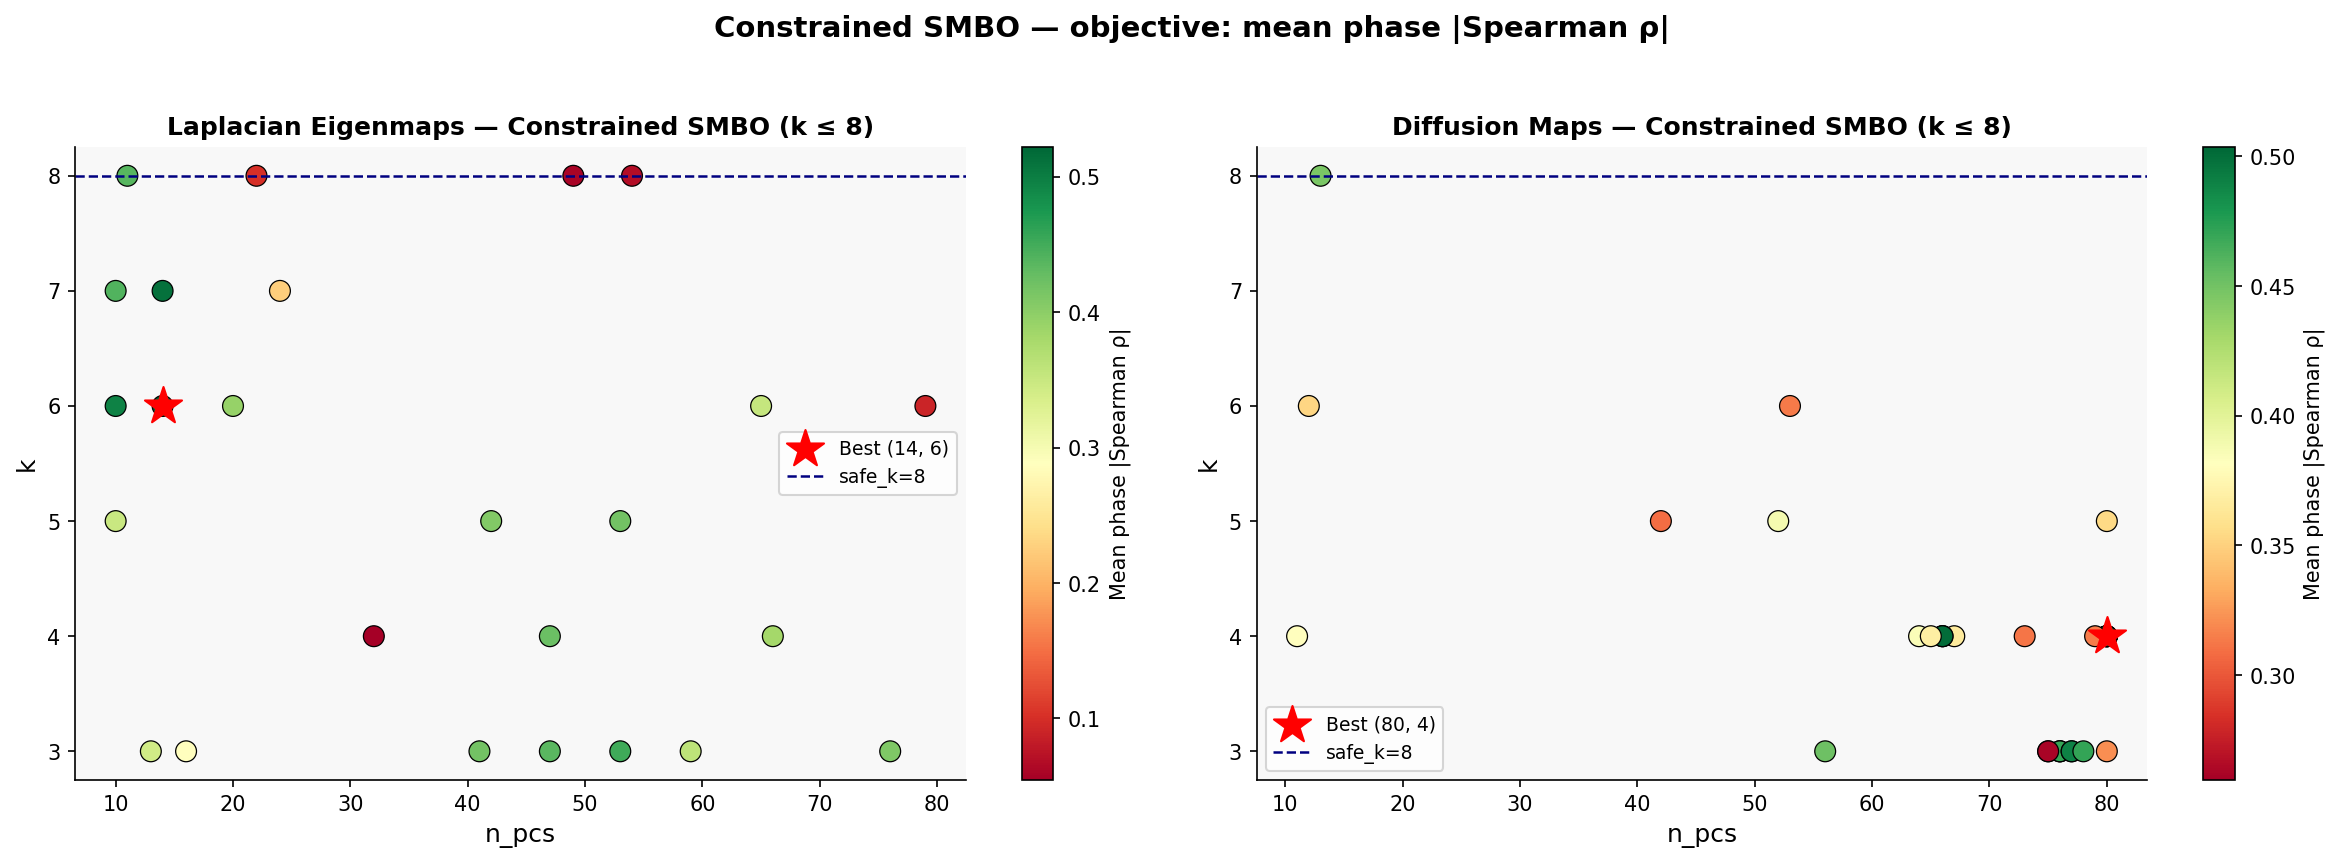

Laplacian top 5:
 n_pcs  k    score
    14  6 0.521986
    14  7 0.511178
    10  6 0.495170
    53  3 0.451339
    10  7 0.440733

Diffusion top 5:
 n_pcs  k    alpha    score
    80  4 0.007202 0.503586
    66  4 0.772226 0.501413
    66  4 0.779691 0.501368
    80  4 0.003838 0.500802
    80  4 0.002167 0.499894


In [28]:
lap_df  = pd.DataFrame(
    [(r[0], r[1], r[3]) for r in lap_eval_log if r[3] is not np.nan],
    columns=['n_pcs', 'k', 'score']
).dropna()
diff_df = pd.DataFrame(
    [(r[0], r[1], r[2], r[4]) for r in diff_eval_log if r[4] is not np.nan],
    columns=['n_pcs', 'k', 'alpha', 'score']
).dropna()

fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=150)
fig.patch.set_facecolor('white')

for ax, df, best_npcs, best_k, title in zip(
    axes,
    [lap_df,         diff_df],
    [best_n_pcs_lap, best_n_pcs_diff],
    [best_k_lap,     best_k_diff],
    ['Laplacian Eigenmaps', 'Diffusion Maps'],
):
    sc_ = ax.scatter(df['n_pcs'], df['k'], c=df['score'],
                     cmap='RdYlGn', s=100, edgecolors='black', linewidth=0.6)
    ax.scatter(best_npcs, best_k, s=350, marker='*', color='red', zorder=5,
               label=f'Best ({best_npcs}, {best_k})')
    ax.axhline(safe_k, color='navy', linestyle='--', linewidth=1.2,
               label=f'safe_k={safe_k}')
    plt.colorbar(sc_, ax=ax, label='Mean phase |Spearman ρ|')
    ax.set_xlabel('n_pcs', fontsize=12)
    ax.set_ylabel('k', fontsize=12)
    ax.set_title(f'{title} — Constrained SMBO (k ≤ {safe_k})',
                 fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.set_facecolor('#F8F8F8')
    ax.spines[['top', 'right']].set_visible(False)

plt.suptitle('Constrained SMBO — objective: mean phase |Spearman ρ|',
             fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig('constrained_smbo_landscape.jpg', dpi=150, bbox_inches='tight')
plt.show()

print('Laplacian top 5:')
print(lap_df.sort_values('score', ascending=False).head(5).to_string(index=False))
print('\nDiffusion top 5:')
print(diff_df.sort_values('score', ascending=False).head(5).to_string(index=False))


## 11. Build Optimal Embeddings

In [29]:
adata_lap_opt = adata_base.copy()
adata_lap_opt.obsm['X_pca'] = adata_base.obsm['X_pca'][:, :best_n_pcs_lap]

adata_diff_opt = adata_base.copy()
adata_diff_opt.obsm['X_pca'] = adata_base.obsm['X_pca'][:, :best_n_pcs_diff]

print(f'Building Laplacian  (n_pcs={best_n_pcs_lap}, k={best_k_lap}) ...')
emb_lap, eigvals_lap, ps_lap = fullLaplacian(adata_lap_opt, k=best_k_lap)
ang_pt_lap = angular_pseudotime(emb_lap, adata_lap_opt)
print(f'  Eigenvalues: {eigvals_lap}')

print(f'\nBuilding Diffusion  (n_pcs={best_n_pcs_diff}, k={best_k_diff}, alpha={best_alpha_diff:.3f}) ...')
emb_diff, lambdas, psis, dpt = run_diffusion(
    adata_diff_opt, k=best_k_diff, alpha=best_alpha_diff)
ang_pt_diff = angular_pseudotime(emb_diff, adata_diff_opt)
print(f'  Top eigenvalues: {lambdas[:5]}')

Building Laplacian  (n_pcs=14, k=6) ...
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
  Eigenvalues: [0.03547828 0.04631305]

Building Diffusion  (n_pcs=80, k=4, alpha=0.007) ...
  Top eigenvalues: [0.94539718 0.89429515 0.84314591 0.81771308 0.80241146]


## 11b. Circular Embedding & Polar Plots

For each method:
- **Circular embedding** — 2-D scatter coloured by `cc_phase`, with the best-fit circle overlaid.
- **Polar plot** — cells placed at their angular pseudotime (radius = 1), coloured by phase, so the cyclic ordering can be read directly off the unit circle.


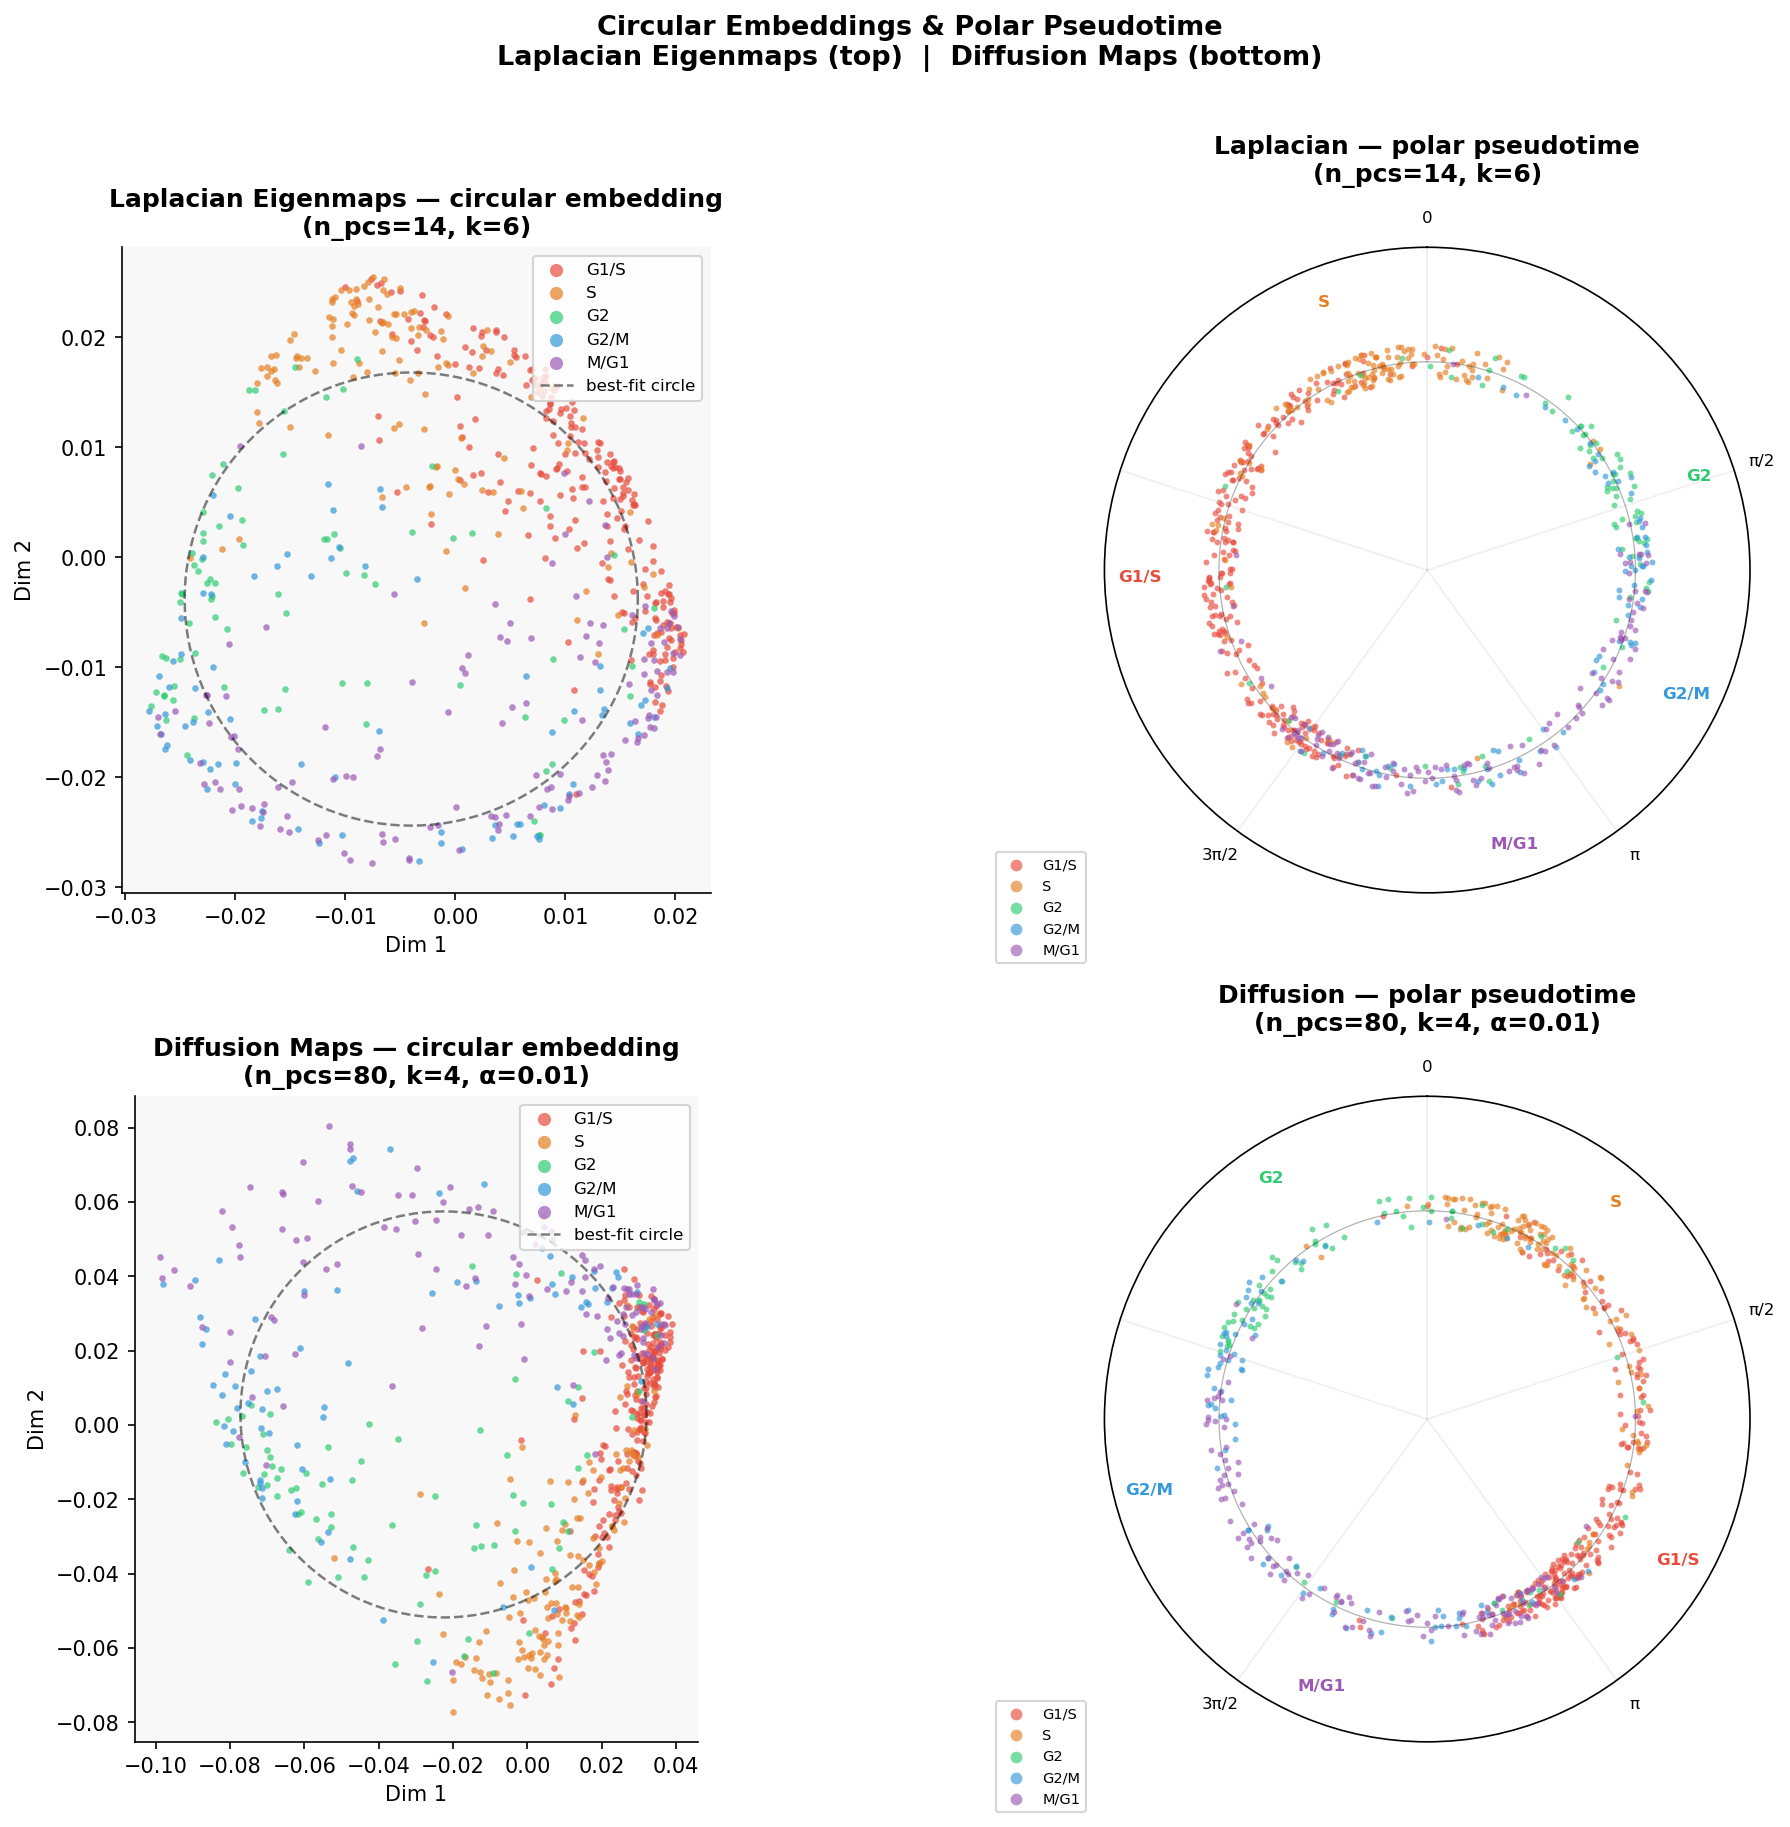

Saved: circular_polar_plots.jpg


In [30]:
# ── Colour palette — one colour per phase ────────────────────────────────────
_PHASE_COLORS = {
    'G1/S': '#E74C3C',
    'S':    '#E67E22',
    'G2':   '#2ECC71',
    'G2/M': '#3498DB',
    'M/G1': '#9B59B6',
}


def _best_fit_circle(xy):
    """Return (cx, cy, r) of the algebraic best-fit circle."""
    from scipy.optimize import least_squares
    x, y = xy[:, 0], xy[:, 1]
    def res(c):
        r = np.sqrt((x - c[0])**2 + (y - c[1])**2)
        return r - r.mean()
    result = least_squares(res, [x.mean(), y.mean()])
    cx, cy = result.x
    r = np.sqrt((x - cx)**2 + (y - cy)**2).mean()
    return cx, cy, r


def plot_circular_embedding(ax, emb, adata, title):
    """
    Scatter of the 2-D embedding coloured by cc_phase,
    with the best-fit circle drawn on top.
    """
    phases = adata.obs['cc_phase'].values
    for ph in PHASE_ORDER:
        mask = phases == ph
        if mask.sum() == 0:
            continue
        ax.scatter(
            emb[mask, 0], emb[mask, 1],
            c=_PHASE_COLORS[ph], label=ph,
            s=10, alpha=0.7, linewidths=0,
        )
    # Best-fit circle
    cx, cy, r = _best_fit_circle(emb[:, :2])
    theta = np.linspace(0, 2 * np.pi, 360)
    ax.plot(cx + r * np.cos(theta), cy + r * np.sin(theta),
            'k--', lw=1.2, alpha=0.5, label='best-fit circle')
    ax.set_aspect('equal')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Dim 1', fontsize=10)
    ax.set_ylabel('Dim 2', fontsize=10)
    ax.set_facecolor('#F8F8F8')
    ax.spines[['top', 'right']].set_visible(False)
    ax.legend(fontsize=8, markerscale=2, loc='upper right')


def plot_polar(ax, ang_pt, adata, title):
    """
    Polar scatter: cells at angle = angular pseudotime, radius jittered
    slightly around 1 so overlapping cells are visible.
    Inner ring shows the phase-label arc means.
    """
    rng    = np.random.default_rng(0)
    phases = adata.obs['cc_phase'].values
    radii  = 1.0 + rng.uniform(-0.08, 0.08, size=len(ang_pt))

    for ph in PHASE_ORDER:
        mask = phases == ph
        if mask.sum() == 0:
            continue
        ax.scatter(
            ang_pt[mask], radii[mask],
            c=_PHASE_COLORS[ph], label=ph,
            s=8, alpha=0.65, linewidths=0,
        )

    # Phase arc labels at radius 1.35
    for ph in PHASE_ORDER:
        mask = phases == ph
        if mask.sum() == 0:
            continue
        mean_angle = np.arctan2(
            np.sin(ang_pt[mask]).mean(),
            np.cos(ang_pt[mask]).mean(),
        ) % TWOPI
        ax.text(
            mean_angle, 1.38, ph,
            ha='center', va='center',
            fontsize=8, fontweight='bold',
            color=_PHASE_COLORS[ph],
        )

    # Unit circle guide
    ax.plot(np.linspace(0, TWOPI, 360), np.ones(360),
            'k-', lw=0.6, alpha=0.3)

    ax.set_title(title, fontsize=12, fontweight='bold', pad=14)
    ax.set_theta_zero_location('N')   # 0 rad at top
    ax.set_theta_direction(-1)        # clockwise = forward in cycle
    ax.set_rlim(0, 1.55)
    ax.set_rticks([])
    ax.set_xticks(np.linspace(0, 2 * np.pi, 5, endpoint=False))
    ax.set_xticklabels(['0', 'π/2', 'π', '3π/2', ''], fontsize=8)
    ax.grid(True, alpha=0.2)
    ax.legend(fontsize=7, markerscale=2,
              loc='lower left', bbox_to_anchor=(-0.18, -0.12))


# ── Figure: 2 rows × 2 cols  (circular embedding | polar) ────────────────────
fig = plt.figure(figsize=(14, 12), dpi=150)
fig.patch.set_facecolor('white')

ax_lap_circ  = fig.add_subplot(2, 2, 1)
ax_lap_polar = fig.add_subplot(2, 2, 2, projection='polar')
ax_diff_circ = fig.add_subplot(2, 2, 3)
ax_diff_polar= fig.add_subplot(2, 2, 4, projection='polar')

plot_circular_embedding(
    ax_lap_circ, emb_lap[:, :2], adata_lap_opt,
    f'Laplacian Eigenmaps — circular embedding\n'
    f'(n_pcs={best_n_pcs_lap}, k={best_k_lap})',
)
plot_polar(
    ax_lap_polar, ang_pt_lap, adata_lap_opt,
    f'Laplacian — polar pseudotime\n'
    f'(n_pcs={best_n_pcs_lap}, k={best_k_lap})',
)
plot_circular_embedding(
    ax_diff_circ, emb_diff[:, :2], adata_diff_opt,
    f'Diffusion Maps — circular embedding\n'
    f'(n_pcs={best_n_pcs_diff}, k={best_k_diff}, α={best_alpha_diff:.2f})',
)
plot_polar(
    ax_diff_polar, ang_pt_diff, adata_diff_opt,
    f'Diffusion — polar pseudotime\n'
    f'(n_pcs={best_n_pcs_diff}, k={best_k_diff}, α={best_alpha_diff:.2f})',
)

plt.suptitle(
    'Circular Embeddings & Polar Pseudotime\n'
    'Laplacian Eigenmaps (top)  |  Diffusion Maps (bottom)',
    fontsize=13, fontweight='bold', y=1.01,
)
plt.tight_layout()
plt.savefig('circular_polar_plots.jpg', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: circular_polar_plots.jpg')


## 12. Robustness — Subsample Stability

In [31]:
def wrap_angle(x):    return np.mod(x, TWOPI)
def circ_mean(a):     return np.arctan2(np.sin(a).sum(), np.cos(a).sum())
def circular_mean(a): return np.arctan2(np.mean(np.sin(a)), np.mean(np.cos(a)))

def aligned_circular_agreement(t1, t2):
    t1, t2 = np.asarray(t1), np.asarray(t2)
    if len(t1) == 0: return 0.0
    a_fwd = np.arctan2(np.sum(np.sin(t1-t2)), np.sum(np.cos(t1-t2)))
    fwd   = np.mean(np.cos(t1 - t2 - a_fwd))
    a_rev = np.arctan2(np.sum(np.sin(t1+t2)), np.sum(np.cos(t1+t2)))
    rev   = np.mean(np.cos(t1 + t2 - a_rev))
    return float(max(fwd, rev))

def align_circular_pseudotime(tf, ts):
    tf, ts = wrap_angle(np.asarray(tf)), wrap_angle(np.asarray(ts))
    best = None
    for s in [1, -1]:
        tt      = wrap_angle(s * ts)
        delta   = circ_mean(wrap_angle(tf - tt))
        aligned = wrap_angle(tt + delta)
        score   = np.mean(np.cos(tf - aligned))
        cand    = {'aligned': aligned, 'score': score}
        if best is None or cand['score'] > best['score']:
            best = cand
    return best

def generate_subsample_indices(n_cells, n_trials=10, frac=0.8, seed=42):
    n_sample = int(n_cells * frac)
    rng = np.random.default_rng(seed)
    return [np.sort(rng.choice(n_cells, n_sample, replace=False))
            for _ in range(n_trials)]

def _phase_corrs(adata, ang_pt_full, ang_pt_sub, idx):
    phases_sub  = adata.obs['cc_phase'].values[idx]
    phase_corrs = {}
    for ph in PHASE_ORDER:
        mask = phases_sub == ph
        phase_corrs[ph] = (
            aligned_circular_agreement(ang_pt_full[idx][mask], ang_pt_sub[mask])
            if mask.sum() >= 3 else np.nan)
    return {'idx': idx, 'ang_pt_sub': ang_pt_sub,
            'ang_pt_full': ang_pt_full[idx],
            'phases': phases_sub, 'phase_corrs': phase_corrs}


def subsample_stability_lap(adata, embedding, k, indices):
    """
    Subsample stability for Laplacian Eigenmaps.
    Uses custom weighted KNN (via loadAndCSR which internally uses k-NN).
    """
    from trajectory_inference.Laplacian_Eigenmaps import loadAndCSR, laplacianEigenmaps
    ang_pt_full = angular_pseudotime(embedding, adata)
    correlations, trial_data = [], []
    for t, idx in enumerate(indices):
        adata_sub  = adata[idx].copy()
        # loadAndCSR uses the module's kNN — k constrained by safe_k
        csr_sub    = loadAndCSR(adata_sub, k)
        emb_sub, _ = laplacianEigenmaps(csr_sub)
        apt_sub    = angular_pseudotime(emb_sub, adata_sub)
        corr       = aligned_circular_agreement(ang_pt_full[idx], apt_sub)
        correlations.append(corr)
        trial_data.append(_phase_corrs(adata, ang_pt_full, apt_sub, idx))
        print(f'  Trial {t+1}/{len(indices)}: agreement = {corr:.3f}')
    print(f'  Stability: {np.mean(correlations):.3f} +/- {np.std(correlations):.3f}')
    return correlations, trial_data


def subsample_stability_diff(adata, embedding, k, alpha, indices):
    ang_pt_full = angular_pseudotime(embedding, adata)
    correlations, trial_data = [], []
    for t, idx in enumerate(indices):
        adata_sub        = adata[idx].copy()
        emb_sub, _, _, _ = run_diffusion(adata_sub, k=k, alpha=alpha)
        apt_sub          = angular_pseudotime(emb_sub, adata_sub)
        corr             = aligned_circular_agreement(ang_pt_full[idx], apt_sub)
        correlations.append(corr)
        trial_data.append(_phase_corrs(adata, ang_pt_full, apt_sub, idx))
        print(f'  Trial {t+1}/{len(indices)}: agreement = {corr:.3f}')
    print(f'  Stability: {np.mean(correlations):.3f} +/- {np.std(correlations):.3f}')
    return correlations, trial_data


assert adata_lap_opt.n_obs == adata_diff_opt.n_obs
shared_idx = generate_subsample_indices(adata_base.n_obs, n_trials=N_TRIALS)

print('=' * 50)
print('Laplacian — Subsample Stability')
print('=' * 50)
lap_sub_corrs, lap_trial_data = subsample_stability_lap(
    adata_lap_opt, emb_lap, k=best_k_lap, indices=shared_idx)

print()
print('=' * 50)
print('Diffusion — Subsample Stability')
print('=' * 50)
diff_sub_corrs, diff_trial_data = subsample_stability_diff(
    adata_diff_opt, emb_diff, k=best_k_diff, alpha=best_alpha_diff, indices=shared_idx)

Laplacian — Subsample Stability
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
  Trial 1/10: agreement = 0.912
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
  Trial 2/10: agreement = 0.966
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
  Trial 3/10: agreement = 0.453
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
  Trial 4/10: agreement = 0.988
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
  Trial 5/10: agreement = 0.976
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
  Trial 6/10: agreement = 0.982
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
  Trial 7/10: agreement = 0.975
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
  Trial 8/10: agreement = 0.720
Running Weighted KNN:
Creating Adjacency Matrix..
Constructing Graph...
  Trial 9/10: agreement = 0.976
Running Weighted KNN:
Creating A

## 13. Robustness — Phase Score Correlations

In [32]:
def phase_score_correlations(adata, ang_pt, label=''):
    phase_names = list(adata.obs['cc_phase'].cat.categories)
    z = adata.obsm['phase_scores_z']
    results = {}
    print(f'  {label}')
    for j, ph in enumerate(phase_names):
        rho, pval = spearmanr(ang_pt, z[:, j])
        results[ph] = {'rho': rho, 'p': pval}
        print(f'    {ph:5s}: rho = {rho:+.3f},  p = {pval:.2e}')
    return results


print('Phase score correlations (constrained-optimal parameters)\n')
lap_phase_corr  = phase_score_correlations(adata_lap_opt,  ang_pt_lap,  'Laplacian')
print()
diff_phase_corr = phase_score_correlations(adata_diff_opt, ang_pt_diff, 'Diffusion')

print('\nPer-trial phase agreement (Laplacian):')
for ph in PHASE_ORDER:
    vals = [td['phase_corrs'].get(ph, np.nan) for td in lap_trial_data]
    vals = [v for v in vals if not np.isnan(v)]
    print(f'  {ph:5s}: {np.mean(vals):.3f} +/- {np.std(vals):.3f}  (n={len(vals)})')

print('\nPer-trial phase agreement (Diffusion):')
for ph in PHASE_ORDER:
    vals = [td['phase_corrs'].get(ph, np.nan) for td in diff_trial_data]
    vals = [v for v in vals if not np.isnan(v)]
    print(f'  {ph:5s}: {np.mean(vals):.3f} +/- {np.std(vals):.3f}  (n={len(vals)})')

Phase score correlations (constrained-optimal parameters)

  Laplacian
    G1/S : rho = +0.613,  p = 1.89e-70
    S    : rho = +0.528,  p = 2.26e-49
    G2   : rho = -0.446,  p = 4.29e-34
    G2/M : rho = -0.637,  p = 9.29e-78
    M/G1 : rho = -0.386,  p = 2.79e-25

  Diffusion
    G1/S : rho = -0.430,  p = 1.60e-31
    S    : rho = -0.728,  p = 1.28e-111
    G2   : rho = +0.190,  p = 6.99e-07
    G2/M : rho = +0.596,  p = 1.19e-65
    M/G1 : rho = +0.575,  p = 2.78e-60

Per-trial phase agreement (Laplacian):
  G1/S : 0.870 +/- 0.194  (n=10)
  S    : 0.886 +/- 0.106  (n=10)
  G2   : 0.828 +/- 0.189  (n=10)
  G2/M : 0.901 +/- 0.149  (n=10)
  M/G1 : 0.878 +/- 0.142  (n=10)

Per-trial phase agreement (Diffusion):
  G1/S : 0.981 +/- 0.006  (n=10)
  S    : 0.976 +/- 0.004  (n=10)
  G2   : 0.967 +/- 0.008  (n=10)
  G2/M : 0.969 +/- 0.012  (n=10)
  M/G1 : 0.981 +/- 0.008  (n=10)


## 14. Robustness Plots

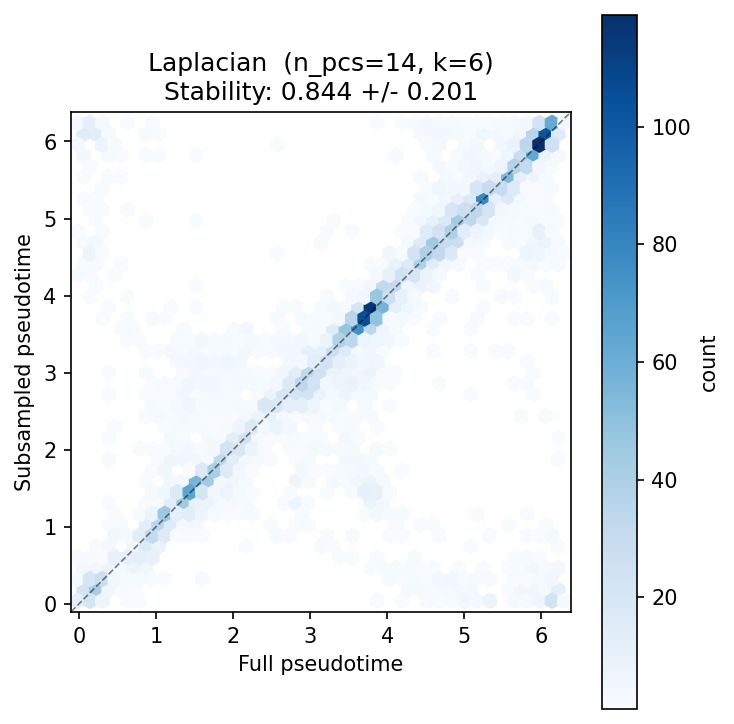

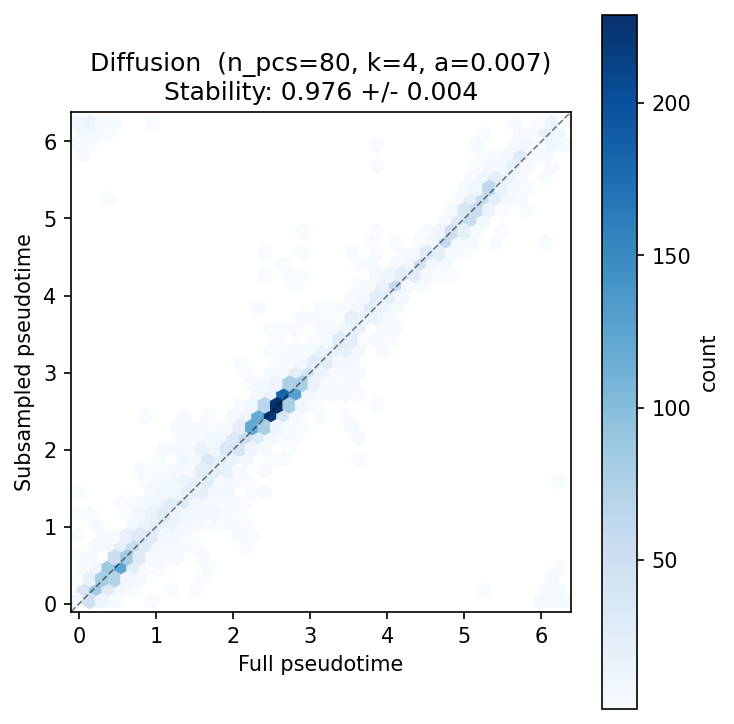

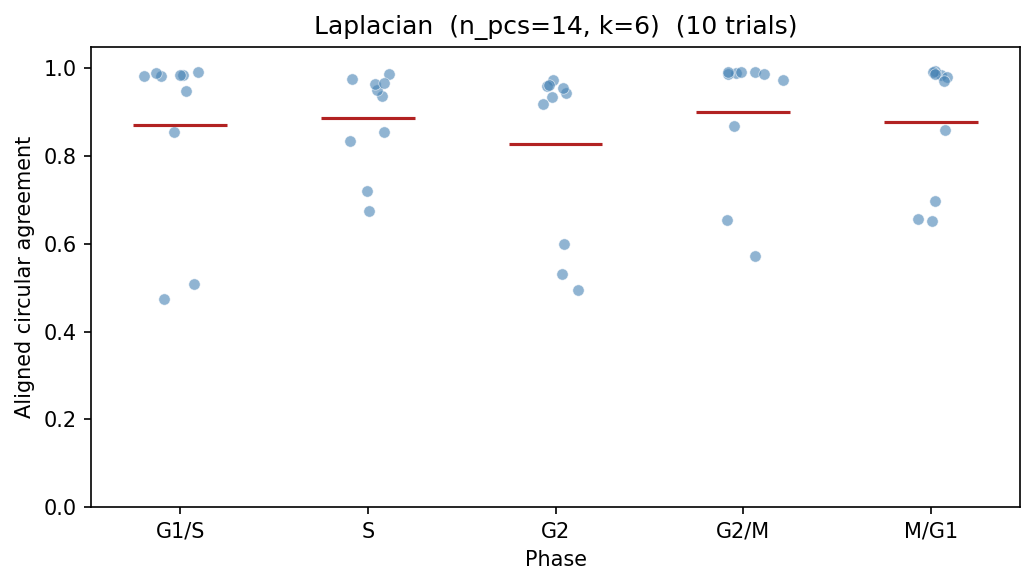

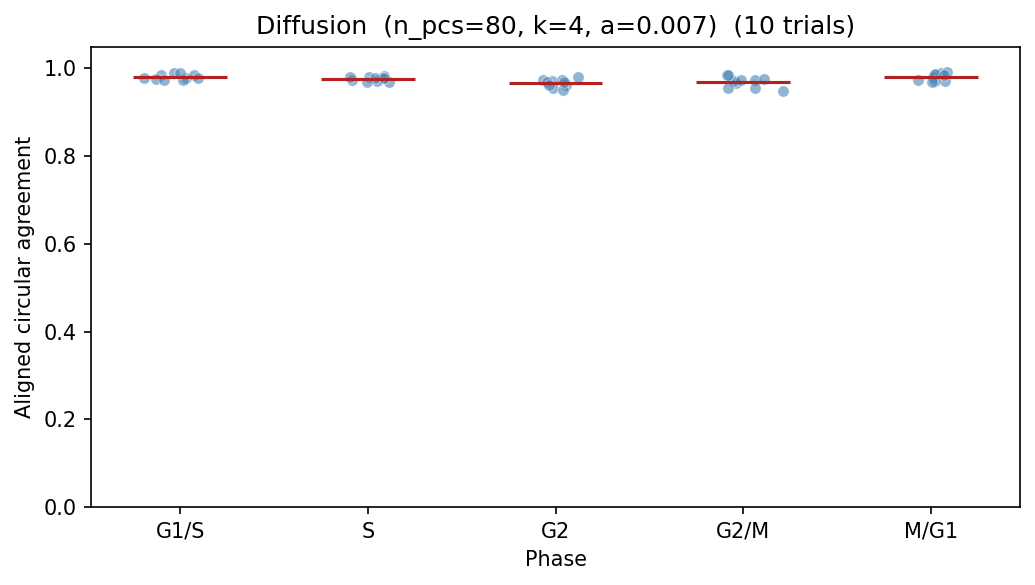

In [33]:
def plot_hexbin(trial_data, correlations, title, save_path=None):
    full_all, sub_all = [], []
    for td in trial_data:
        tf   = np.asarray(td['ang_pt_full'])
        ts   = np.asarray(td['ang_pt_sub'])
        best = align_circular_pseudotime(tf, ts)
        full_all.append(tf)
        sub_all.append(best['aligned'])
    full_all = np.concatenate(full_all)
    sub_all  = np.concatenate(sub_all)
    lo = min(full_all.min(), sub_all.min()) - 0.1
    hi = max(full_all.max(), sub_all.max()) + 0.1
    fig, ax = plt.subplots(figsize=(5, 5), dpi=150)
    hb = ax.hexbin(full_all, sub_all, gridsize=40, cmap='Blues',
                   mincnt=1, extent=(lo, hi, lo, hi))
    fig.colorbar(hb, ax=ax, label='count')
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.5)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi); ax.set_aspect('equal')
    ax.set_xlabel('Full pseudotime'); ax.set_ylabel('Subsampled pseudotime')
    ax.set_title(
        f'{title}\nStability: {np.mean(correlations):.3f} +/- {np.std(correlations):.3f}')
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


def plot_phase_agreement(trial_data, title, save_path=None):
    fig, ax = plt.subplots(figsize=(7, 4), dpi=150)
    rng = np.random.default_rng(42)
    for i, ph in enumerate(PHASE_ORDER):
        vals   = [td['phase_corrs'].get(ph, np.nan) for td in trial_data]
        vals   = [v for v in vals if not np.isnan(v)]
        jitter = i + 0.1 * rng.standard_normal(len(vals))
        ax.scatter(jitter, vals, s=30, alpha=0.6, color='steelblue',
                   edgecolors='white', linewidths=0.4, zorder=3)
        if vals:
            ax.hlines(np.mean(vals), i-0.25, i+0.25,
                      colors='firebrick', lw=1.5, zorder=4)
    ax.set_xticks(range(len(PHASE_ORDER)))
    ax.set_xticklabels(PHASE_ORDER)
    ax.set_ylim(0, 1.05)
    ax.set_xlabel('Phase'); ax.set_ylabel('Aligned circular agreement')
    ax.set_title(f'{title}  ({len(trial_data)} trials)')
    plt.tight_layout()
    if save_path: fig.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()


plot_hexbin(lap_trial_data,  lap_sub_corrs,
            f'Laplacian  (n_pcs={best_n_pcs_lap}, k={best_k_lap})',
            'robustness_hexbin_laplacian.jpg')
plot_hexbin(diff_trial_data, diff_sub_corrs,
            f'Diffusion  (n_pcs={best_n_pcs_diff}, k={best_k_diff}, a={best_alpha_diff:.3f})',
            'robustness_hexbin_diffusion.jpg')
plot_phase_agreement(lap_trial_data,
                     f'Laplacian  (n_pcs={best_n_pcs_lap}, k={best_k_lap})',
                     'robustness_phase_lap.jpg')
plot_phase_agreement(diff_trial_data,
                     f'Diffusion  (n_pcs={best_n_pcs_diff}, k={best_k_diff}, a={best_alpha_diff:.3f})',
                     'robustness_phase_diff.jpg')

## 15. Final Summary Table

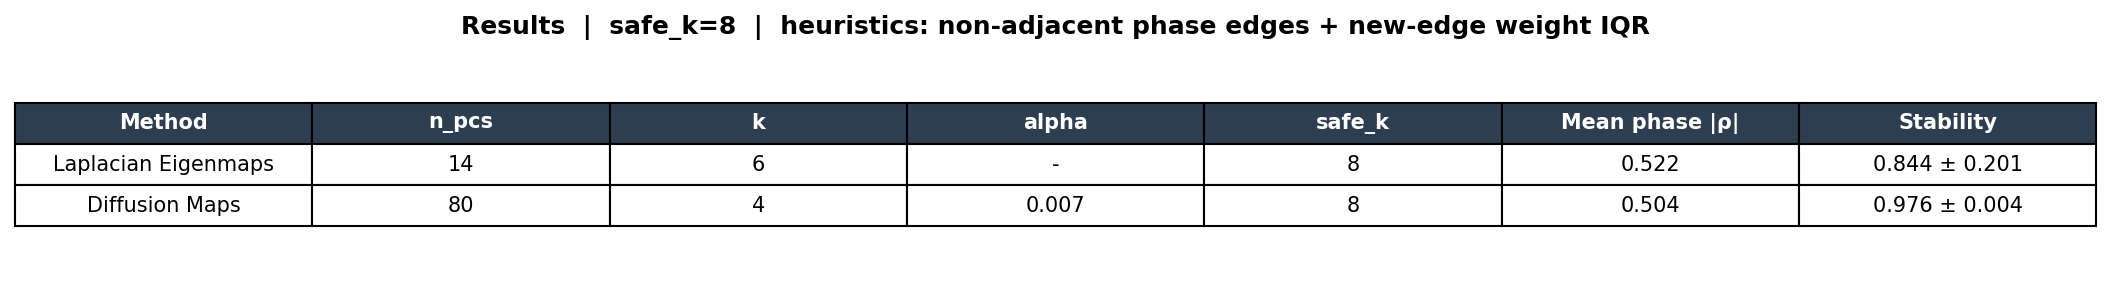

             Method  n_pcs  k alpha  safe_k Mean phase |ρ|     Stability
Laplacian Eigenmaps     14  6     -       8          0.522 0.844 ± 0.201
     Diffusion Maps     80  4 0.007       8          0.504 0.976 ± 0.004


In [34]:
def mean_phase_rho(adata, ang_pt):
    """Mean |Spearman rho| across all phase score columns vs angular pseudotime."""
    z = adata.obsm['phase_scores_z']
    rhos = []
    for j in range(z.shape[1]):
        r, _ = spearmanr(ang_pt, z[:, j])
        if not np.isnan(r):
            rhos.append(abs(r))
    return float(np.mean(rhos)) if rhos else np.nan


ang_lap_opt  = angular_pseudotime(emb_lap,  adata_lap_opt)
ang_diff_opt = angular_pseudotime(emb_diff, adata_diff_opt)
lap_phase_score  = mean_phase_rho(adata_lap_opt,  ang_lap_opt)
diff_phase_score = mean_phase_rho(adata_diff_opt, ang_diff_opt)

summary = pd.DataFrame([
    {
        'Method':              'Laplacian Eigenmaps',
        'n_pcs':              best_n_pcs_lap,
        'k':                  best_k_lap,
        'alpha':              '-',
        'safe_k':             safe_k,
        'Mean phase |ρ|':     f'{lap_phase_score:.3f}',
        'Stability':          f'{np.mean(lap_sub_corrs):.3f} ± {np.std(lap_sub_corrs):.3f}',
    },
    {
        'Method':              'Diffusion Maps',
        'n_pcs':              best_n_pcs_diff,
        'k':                  best_k_diff,
        'alpha':              f'{best_alpha_diff:.3f}',
        'safe_k':             safe_k,
        'Mean phase |ρ|':     f'{diff_phase_score:.3f}',
        'Stability':          f'{np.mean(diff_sub_corrs):.3f} ± {np.std(diff_sub_corrs):.3f}',
    },
])

fig, ax = plt.subplots(figsize=(14, 2), dpi=150)
fig.patch.set_facecolor('white')
ax.axis('off')
tbl = ax.table(cellText=summary.values, colLabels=summary.columns,
               cellLoc='center', loc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.1, 1.8)
for j in range(len(summary.columns)):
    tbl[(0, j)].set_facecolor('#2C3E50')
    tbl[(0, j)].set_text_props(color='white', fontweight='bold')
ax.set_title(
    f'Results  |  safe_k={safe_k}  |  '
    f'heuristics: non-adjacent phase edges + new-edge weight IQR',
    fontsize=12, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('constrained_smbo_summary.jpg', dpi=150, bbox_inches='tight')
plt.show()

print(summary.to_string(index=False))
